# fio DFS Heatmap Sweep — 256 Queue Depth

Analyzes `rand_write` results from a sweep of `(numjobs, iodepth)` pairs
where `numjobs × iodepth = 256` (constant total queue depth), block size = 1 MiB.

In [1]:
import json
import glob
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [2]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job   = d["jobs"][0]
    w     = job["write"]
    slat  = w["slat_ns"]
    clat  = w["clat_ns"]
    lat   = w["lat_ns"]
    cp    = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        numjobs       = nj,
        iodepth       = iod,
        block_size    = bs,
        bw_GiBs       = w["bw"] / 1024 / 1024,
        iops          = w["iops"],
        # submission latency
        slat_min_ms   = ms(slat["min"]),
        slat_mean_ms  = ms(slat["mean"]),
        slat_max_ms   = ms(slat["max"]),
        # completion latency
        clat_50th_ms    = ms(cp["50.000000"]),
        clat_90th_ms    = ms(cp["90.000000"]),
        clat_99th_ms    = ms(cp["99.000000"]),
        clat_99_9th_ms  = ms(cp["99.900000"]),
        clat_99_99th_ms = ms(cp["99.990000"]),
        # total latency
        lat_min_ms    = ms(lat["min"]),
        lat_mean_ms   = ms(lat["mean"]),
        lat_max_ms    = ms(lat["max"]),
    )

files = sorted(RESULTS_DIR.glob("*.json"))
df = pd.DataFrame([parse_file(f) for f in files]).sort_values("numjobs").reset_index(drop=True)
df["label"] = df.apply(lambda r: f"nj={r.numjobs}\niod={r.iodepth}", axis=1)
print(f"Loaded {len(df)} result files")

df

Loaded 5 result files


,numjobs,iodepth,block_size,bw_GiBs,iops,slat_min_ms,slat_mean_ms,slat_max_ms,clat_50th_ms,clat_90th_ms,clat_99th_ms,clat_99_9th_ms,clat_99_99th_ms,lat_min_ms,lat_mean_ms,lat_max_ms,label
0,4,64,1M,21.543531,22060.576779,0.023681,0.034956,5.908618,5.603328,18.743296,103.284736,133.693440,149.946368,0.895370,11.521331,164.952732,nj=4\niod=64
1,8,32,1M,22.105309,22635.836610,0.024941,0.035581,9.325400,8.224768,17.956864,42.729472,68.681728,88.604672,0.515119,11.226907,161.499401,nj=8\niod=32
2,16,16,1M,22.969672,23520.945113,0.024780,0.036782,16.630482,9.371648,16.580608,26.345472,39.583744,71.827456,0.308106,10.800903,95.818454,nj=16\niod=16
3,32,8,1M,22.706928,23251.895296,0.026691,0.041656,48.582688,10.158080,11.730944,20.578304,30.801920,49.545216,0.328327,10.923915,83.059317,nj=32\niod=8
4,64,4,1M,22.931343,23481.695633,0.026781,0.052837,59.077628,10.420224,10.944512,20.054016,30.277632,58.982400,0.299047,10.815804,131.999720,nj=64\niod=4


## Bandwidth & IOPS

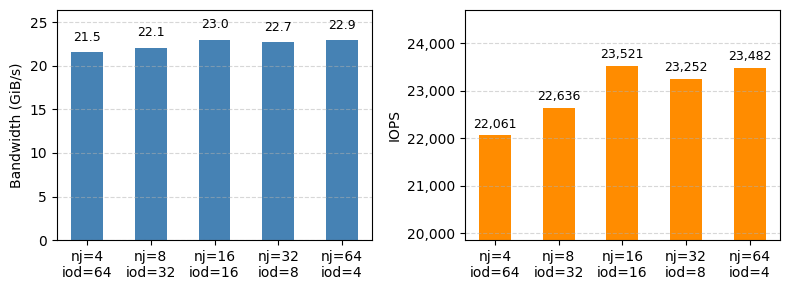

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(df["label"], df["bw_GiBs"], color="steelblue", width=0.5)
axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_ylim(0, df["bw_GiBs"].max() * 1.15)
for bar, v in zip(axes[0].patches, df["bw_GiBs"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v:,.1f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(df["label"], df["iops"], color="darkorange", width=0.5)
axes[1].set_ylabel("IOPS")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].set_ylim(df["iops"].min() * 0.9, df["iops"].max() * 1.05)
for bar, v in zip(axes[1].patches, df["iops"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

for ax in axes:
    # ax.set_xlabel("numjobs / iodepth")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bw_iops.pdf", dpi=150)
plt.show()

## Latency Plot

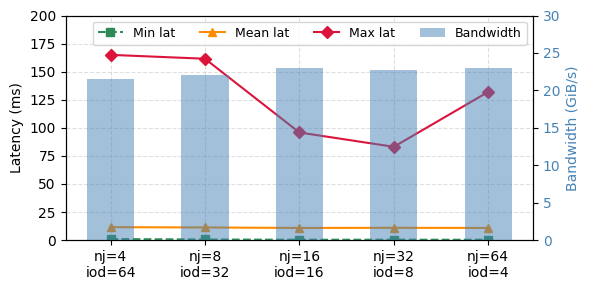

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))

# --- right axis: bandwidth bars ---
ax2 = ax.twinx()
ax2.bar(range(len(df)), df["bw_GiBs"], color="steelblue", alpha=0.5, width=0.5, zorder=1)
ax2.set_ylabel("Bandwidth (GiB/s)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 30)  # adjust by hand

# --- left axis: latency lines ---
x = range(len(df))
ax.plot(x, df["lat_min_ms"],  "s--", label="Min lat",  color="seagreen",   zorder=3)
ax.plot(x, df["lat_mean_ms"], "^-",  label="Mean lat", color="darkorange", zorder=3)
ax.plot(x, df["lat_max_ms"],  "D-",  label="Max lat",  color="crimson",    zorder=3)
ax.set_ylim(0, 200)  # adjust by hand

ax.set_xticks(list(x))
ax.set_xticklabels(df["label"])
ax.set_ylabel("Latency (ms)")
ax.grid(linestyle="--", alpha=0.4, zorder=0)

# combined legend
lines, labels = ax.get_legend_handles_labels()
from matplotlib.patches import Patch
lines.append(Patch(facecolor="steelblue", alpha=0.5))
labels.append("Bandwidth")
ax.legend(lines, labels, loc="best", ncols=4, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency.pdf", dpi=150)
plt.show()

## Tail Latency Detail

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_33426/3820686036.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _paired = plt.cm.get_cmap("Paired").colors


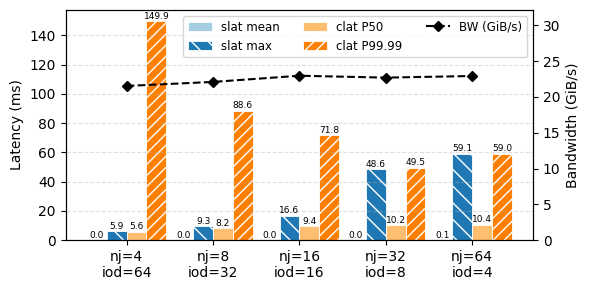

In [16]:
_paired = plt.cm.get_cmap("Paired").colors
COLORS  = [_paired[0], _paired[1], _paired[6], _paired[7]]
HATCHES = ["", "\\\\", "", "///"]

metrics = [
    ("slat_mean_ms",    "slat mean"),
    ("slat_max_ms",    "slat max"),
    ("clat_50th_ms",  "clat P50"),
    ("clat_99_99th_ms", "clat P99.99"),
]
n  = len(metrics)
w  = 0.92 / n
x  = list(range(len(df)))
offsets = [(i - (n - 1) / 2) * w for i in range(n)]

fig, ax = plt.subplots(figsize=(6, 3))

for (col, label), offset, color, hatch in zip(metrics, offsets, COLORS, HATCHES):
    bars = ax.bar([xi + offset for xi in x], df[col], w,
                  label=label, color=color, hatch=hatch,
                  edgecolor="white", linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}", ha="center", va="bottom",
                fontsize=6.5, rotation=0)

# --- right axis: bandwidth line ---
ax2 = ax.twinx()
ax2.plot(x, df["bw_GiBs"], "D--", color="black", linewidth=1.5,
         markersize=5, label="BW (GiB/s)", zorder=5)
# for xi, bw in zip(x, df["bw_GiBs"]):
#     ax2.text(xi, bw + 0.15, f"{bw:.1f}", ha="center", va="bottom",
#              fontsize=6.5, color="black")
ax2.set_ylabel("Bandwidth (GiB/s)", color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(0, df["bw_GiBs"].max() * 1.4)

ax.set_xticks(x)
ax.set_xticklabels(df["label"])
ax.set_ylabel("Latency (ms)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# combined legend
bar_handles, bar_labels = ax.get_legend_handles_labels()
line_handles, line_labels = ax2.get_legend_handles_labels()
ax.legend(bar_handles + line_handles, bar_labels + line_labels,
          ncol=3, loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "tail_latency_breakdown.pdf", dpi=150)
plt.show()


## Submit Batch Size

In [6]:
submit_rows = []
for f in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs\S+?_nj(\d+)_iod(\d+)_", f.name)
    nj, iod = int(m.group(1)), int(m.group(2))
    with open(f) as fh:
        d = json.load(fh)
    submit = d["jobs"][0]["iodepth_submit"]
    submit_rows.append({"numjobs": nj, "iodepth": iod, **{f"submit_{k}": v for k, v in submit.items()}})

df_submit = pd.DataFrame(submit_rows).sort_values("numjobs").reset_index(drop=True)
df_submit

,numjobs,iodepth,submit_0,submit_4,submit_8,submit_16,submit_32,submit_64,submit_>=64
0,4,64,0.0,100.0,0.0,0.0,0.0,0.0,0.0
1,8,32,0.0,100.0,0.0,0.0,0.0,0.0,0.0
2,16,16,0.0,100.0,0.0,0.0,0.0,0.0,0.0
3,32,8,0.0,100.0,0.0,0.0,0.0,0.0,0.0
4,64,4,0.0,100.0,0.0,0.0,0.0,0.0,0.0


Across all configurations, `iodepth_submit["4"] = 100%` regardless of the configured `iodepth` (4, 8, 16, 32, or 64). This is a fixed behavior of the DAOS DFS ioengine: it submits IOs in batches of 4 internally (via `daos_eq_poll` or equivalent), so the submit batch size never reflects the configured iodepth. The configured `iodepth` only controls the maximum number of IOs allowed in-flight simultaneously — not how many are issued per submission call.

## Queue Depth Utilization (iodepth_level)

In [7]:
level_rows = []
for f in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs\S+?_nj(\d+)_iod(\d+)_", f.name)
    nj, iod = int(m.group(1)), int(m.group(2))
    with open(f) as fh:
        d = json.load(fh)
    level = d["jobs"][0]["iodepth_level"]
    level_rows.append({"numjobs": nj, "iodepth": iod, **{f"level_{k}": v for k, v in level.items()}})

df_level = pd.DataFrame(level_rows).sort_values("numjobs").reset_index(drop=True)
df_level

,numjobs,iodepth,level_1,level_2,level_4,level_8,level_16,level_32,level_>=64
0,4,64,0.1,0.1,0.100000,0.100000,0.100000,0.100000,99.980969
1,8,32,0.1,0.1,0.100000,0.100000,0.100000,99.981748,0.000000
2,16,16,0.1,0.1,0.100000,0.100000,99.982998,0.000000,0.000000
3,32,8,0.1,0.1,0.100000,99.983949,0.000000,0.000000,0.000000
4,64,4,0.1,0.1,99.986375,0.000000,0.000000,0.000000,0.000000


All configurations keep the queue nearly full at their configured iodepth (~99.98–100% of the time), confirming the workload is genuinely saturating each job's queue. The small residual at lower levels (≤0.1%) corresponds to ramp-up and cooldown at the start/end of each 60 s run.

## CPU Usage (usr / sys)

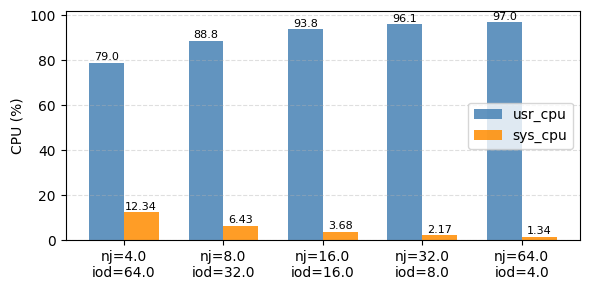

In [8]:
cpu_rows = []
for f in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs\S+?_nj(\d+)_iod(\d+)_", f.name)
    nj, iod = int(m.group(1)), int(m.group(2))
    with open(f) as fh:
        d = json.load(fh)
    job = d["jobs"][0]
    cpu_rows.append(dict(numjobs=nj, iodepth=iod,
                         usr_cpu=job["usr_cpu"], sys_cpu=job["sys_cpu"]))

df_cpu = pd.DataFrame(cpu_rows).sort_values("numjobs").reset_index(drop=True)
df_cpu["label"] = df_cpu.apply(lambda r: f"nj={r.numjobs}\niod={r.iodepth}", axis=1)

x  = range(len(df_cpu))
w  = 0.35
fig, ax = plt.subplots(figsize=(6, 3))

bars_usr = ax.bar([xi - w/2 for xi in x], df_cpu["usr_cpu"], w,
                  label="usr_cpu", color="steelblue", alpha=0.85)
bars_sys = ax.bar([xi + w/2 for xi in x], df_cpu["sys_cpu"], w,
                  label="sys_cpu", color="darkorange", alpha=0.85)

for bar in bars_usr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
for bar in bars_sys:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_cpu["label"])
ax.set_ylabel("CPU (%)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Claude Key Findings

**Workload:** `rand_write`, bs=1M, total queue depth fixed at 256 (numjobs × iodepth = 256)

### 1. Bandwidth is flat across configurations
Write bandwidth is consistently regardless of how queue depth is split. The nj=4/iod=64 configuration is weakest (~21.5 GiB/s); all others exceed 22.1 GiB/s. The DFS backend is not bandwidth-limited by queue depth distribution at this scale.

### 2. Tail latency degrades sharply with deep per-job iodepth
p99 completion latency drops dramatically as iodepth per job decreases:
- **nj=4, iod=64:** clat p99 = 103 ms, p99.99 = 150 ms — worst configuration
- **nj=64, iod=4:** clat p99 = 20 ms, p99.99 = 59 ms — ~5× better p99

High per-job iodepth causes intra-job queuing that inflates tail latencies without bandwidth gains.

### 3. Mean latency is deceptively stable
Mean latency varies only 10.8–11.5 ms across all configurations, masking large tail differences. p50 latency is more informative: it rises from 5.6 ms (nj=4) to 10.4 ms (nj=64), reflecting the latency distribution shift.

### 4. Sweet spot: nj=32 or nj=64 with low iodepth
Both nj=32/iod=8 and nj=64/iod=4 achieve the best tail latency (p99 ~20 ms, p99.9 ~30 ms) with competitive bandwidth. Between them, **nj=32/iod=8** has lower p99.99 (49.6 ms vs 59.0 ms), making it the best balanced configuration.

**Recommendation:** For 1M write workloads on DAOS DFS with total QD=256, prefer more jobs with lower per-job iodepth (nj=32–64, iod=4–8). This minimizes tail latency with no meaningful bandwidth cost. 